# Proyek Analisis Data: Bike Sharing Dataset
- **Nama:** Jesika Yudiani Putri
- **Email:** jesika.yudiani.p7@gmail.com
- **ID Dicoding:** Jesika Yudiani Putri

## Menentukan Pertanyaan Bisnis

- Pertanyaan 1 : Bagaimana pengaruh kondisi cuaca (weathersit) terhadap jumlah total penyewaan sepeda (cnt)?
- Pertanyaan 2 : Bagaimana perbandingan pola penyewaan antara penyewa casual dan registered berdasarkan musim (season) dan tahun (yr)?

## Import Semua Packages/Library yang Digunakan

In [5]:
# Import Library
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Mempercantik plots saja
sns.set(style='whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)

## Data Wrangling

### Gathering Data

In [6]:
# Load datasets
day_df = pd.read_csv('data/day.csv')
hour_df = pd.read_csv('data/hour.csv')

# Tampilkan 5 baris pertama dari masing-masing dataset
print("Day dataset sample:")
display(day_df.head())
print("\nHour dataset sample:")
display(hour_df.head())

Day dataset sample:


,instant,dteday,season,yr,mnth,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt
0,1,2011-01-01,1,0,1,0,6,0,2,0.344167,0.363625,0.805833,0.160446,331,654,985
1,2,2011-01-02,1,0,1,0,0,0,2,0.363478,0.353739,0.696087,0.248539,131,670,801
2,3,2011-01-03,1,0,1,0,1,1,1,0.196364,0.189405,0.437273,0.248309,120,1229,1349
3,4,2011-01-04,1,0,1,0,2,1,1,0.200000,0.212122,0.590435,0.160296,108,1454,1562
4,5,2011-01-05,1,0,1,0,3,1,1,0.226957,0.229270,0.436957,0.186900,82,1518,1600



Hour dataset sample:


,instant,dteday,season,yr,mnth,hr,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt
0,1,2011-01-01,1,0,1,0,0,6,0,1,0.24,0.2879,0.81,0.0,3,13,16
1,2,2011-01-01,1,0,1,1,0,6,0,1,0.22,0.2727,0.80,0.0,8,32,40
2,3,2011-01-01,1,0,1,2,0,6,0,1,0.22,0.2727,0.80,0.0,5,27,32
3,4,2011-01-01,1,0,1,3,0,6,0,1,0.24,0.2879,0.75,0.0,3,10,13
4,5,2011-01-01,1,0,1,4,0,6,0,1,0.24,0.2879,0.75,0.0,0,1,1


**Insight:**

- day.csv memiliki 731 baris (data harian selama 2 tahun) dengan 16 kolom.
- hour.csv memiliki 17379 baris (data per jam) dengan 17 kolom.
- Kolom dteday bertipe object (perlu diubah ke datetime), kolom season, weathersit, yr, dll merupakan data kategorikal numerik.

### Assessing Data

In [7]:
# Mengecek info data dan tipe data
print(day_df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 731 entries, 0 to 730
Data columns (total 16 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   instant     731 non-null    int64  
 1   dteday      731 non-null    object 
 2   season      731 non-null    int64  
 3   yr          731 non-null    int64  
 4   mnth        731 non-null    int64  
 5   holiday     731 non-null    int64  
 6   weekday     731 non-null    int64  
 7   workingday  731 non-null    int64  
 8   weathersit  731 non-null    int64  
 9   temp        731 non-null    float64
 10  atemp       731 non-null    float64
 11  hum         731 non-null    float64
 12  windspeed   731 non-null    float64
 13  casual      731 non-null    int64  
 14  registered  731 non-null    int64  
 15  cnt         731 non-null    int64  
dtypes: float64(4), int64(11), object(1)
memory usage: 91.5+ KB
None


In [8]:
# Mengecek duplikasi
print("Duplikasi day_df:", day_df.duplicated().sum())

Duplikasi day_df: 0


In [9]:
# Mengecek missing values
print(day_df.isna().sum())

instant       0
dteday        0
season        0
yr            0
mnth          0
holiday       0
weekday       0
workingday    0
weathersit    0
temp          0
atemp         0
hum           0
windspeed     0
casual        0
registered    0
cnt           0
dtype: int64


In [10]:
# Statistik deskriptif
display(day_df.describe())

,instant,season,yr,mnth,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt
count,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000
mean,366.000000,2.496580,0.500684,6.519836,0.028728,2.997264,0.683995,1.395349,0.495385,0.474354,0.627894,0.190486,848.176471,3656.172367,4504.348837
std,211.165812,1.110807,0.500342,3.451913,0.167155,2.004787,0.465233,0.544894,0.183051,0.162961,0.142429,0.077498,686.622488,1560.256377,1937.211452
min,1.000000,1.000000,0.000000,1.000000,0.000000,0.000000,0.000000,1.000000,0.059130,0.079070,0.000000,0.022392,2.000000,20.000000,22.000000
25%,183.500000,2.000000,0.000000,4.000000,0.000000,1.000000,0.000000,1.000000,0.337083,0.337842,0.520000,0.134950,315.500000,2497.000000,3152.000000
50%,366.000000,3.000000,1.000000,7.000000,0.000000,3.000000,1.000000,1.000000,0.498333,0.486733,0.626667,0.180975,713.000000,3662.000000,4548.000000
75%,548.500000,3.000000,1.000000,10.000000,0.000000,5.000000,1.000000,2.000000,0.655417,0.608602,0.730209,0.233214,1096.000000,4776.500000,5956.000000
max,731.000000,4.000000,1.000000,12.000000,1.000000,6.000000,1.000000,3.000000,0.861667,0.840896,0.972500,0.507463,3410.000000,6946.000000,8714.000000


**Insight:**

- Tidak ada missing values di day.csv
- Tidak ada nilai yang berduplikasi di day.csv
- Kolom dteday perlu diubah ke datetime
- Kolom season, yr, mnth, holiday, weekday, workingday, weathersit merupakan data kategorikal, meskipun disimpan sebagai integer.
- Nilai temp, atemp, hum, windspeed sudah dinormalisasi (rentang 0-1)
- Rentang cnt dari 22 hingga 9795, dengan rata-rata sekitar 4504.

### Cleaning Data

In [11]:
# Convert dteday to datetime
day_df['dteday'] = pd.to_datetime(day_df['dteday'])

In [12]:
# Convert categorical columns to category type
categorical_cols = ['season', 'yr', 'mnth', 'holiday', 'weekday', 'workingday', 'weathersit']
for col in categorical_cols:
    day_df[col] = day_df[col].astype('category')

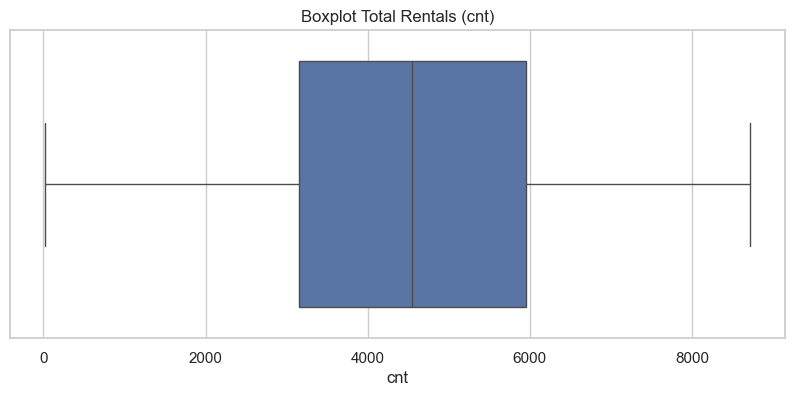

In [13]:
# Cek outlier pada cnt
plt.figure(figsize=(10,4))
sns.boxplot(x=day_df['cnt'])
plt.title('Boxplot Total Rentals (cnt)')
plt.show()

**Insight:**
- Data pada variabel total peminjaman sepeda (cnt) sudah bersih, tetapi perlu konversi tipe data.
- tidak ada outlier

## Exploratory Data Analysis (EDA)

### Explore Distribusi Total Penyewaan

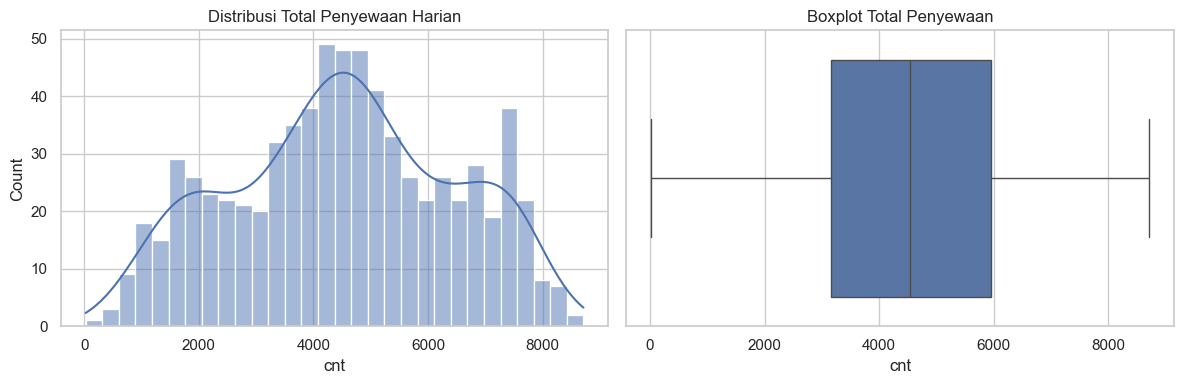

In [14]:
plt.figure(figsize=(12,4))
plt.subplot(1,2,1)
sns.histplot(day_df['cnt'], bins=30, kde=True)
plt.title('Distribusi Total Penyewaan Harian')
plt.subplot(1,2,2)
sns.boxplot(x=day_df['cnt'])
plt.title('Boxplot Total Penyewaan')
plt.tight_layout()
plt.show()

### Korelasi Antar Variabel Numerik

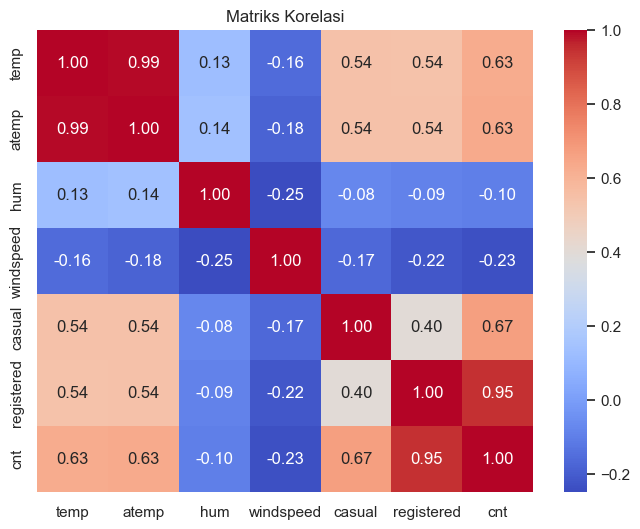

In [15]:
numeric_cols = ['temp', 'atemp', 'hum', 'windspeed', 'casual', 'registered', 'cnt']
corr = day_df[numeric_cols].corr()
plt.figure(figsize=(8,6))
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Matriks Korelasi')
plt.show()

**Insight**

- temp dan atemp berkorelasi positif sedang dengan cnt yaitu sebesar 0.63. Korelasi ini menunjukkan bahwa semakin hangat suhu udara, semakin banyak orang yang menyewa sepeda
- registered sangat berkorelasi dengan cnt (0.95), sedangkan casual lebih lemah (0.67). Korelasi 0.95 itu sangat kuat. Ini berarti naik-turunnya total penyewaan hampir seluruhnya ditentukan oleh perilaku pengguna Registered
- hum berkorelasi negatif lemah (-0.1). Korelasi antara hum dengan cnt ini menunjukkan bahwa kelembapan yang tinggi cenderung sedikit menurunkan minat orang untuk bersepeda

### Tren Tahunan dan Bulanan

C:\Users\user\AppData\Local\Temp\ipykernel_24644\3570203953.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  monthly_cnt = day_df.groupby(['yr', 'mnth'])['cnt'].mean().reset_index()


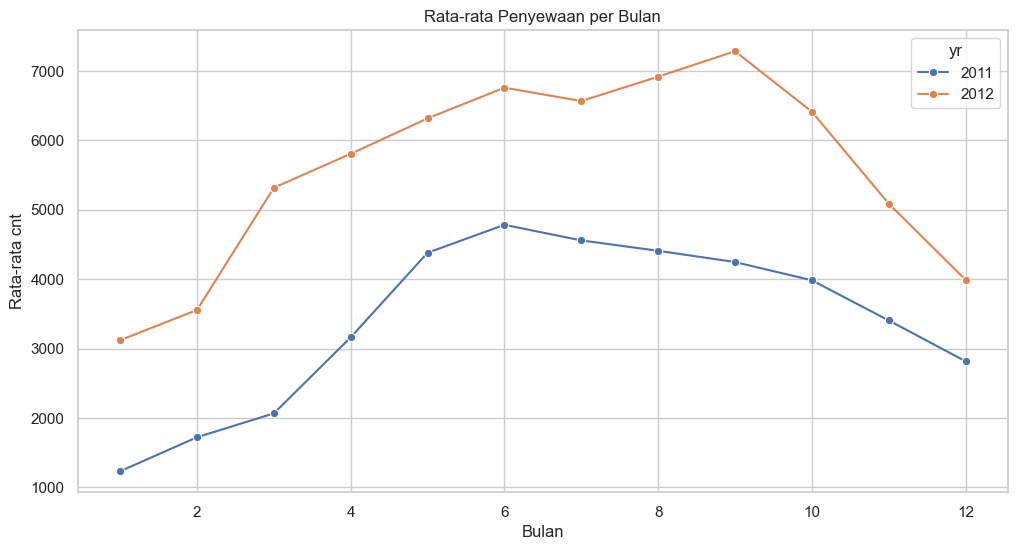

In [16]:
monthly_cnt = day_df.groupby(['yr', 'mnth'])['cnt'].mean().reset_index()
monthly_cnt['yr'] = monthly_cnt['yr'].map({0:'2011', 1:'2012'})
sns.lineplot(data=monthly_cnt, x='mnth', y='cnt', hue='yr', marker='o')
plt.title('Rata-rata Penyewaan per Bulan')
plt.xlabel('Bulan')
plt.ylabel('Rata-rata cnt')
plt.show()

# Insight:

- Terdapat pola musiman yaitu rendah di awal tahun, naik di musim panas, puncak di musim gugur.

## Visualization & Explanatory Analysis

### Pertanyaan 1: Hubungan Cuaca dengan Penyewaan

C:\Users\user\AppData\Local\Temp\ipykernel_24644\4239431809.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  weather_group = day_df.groupby('weathersit')['cnt'].agg(['mean', 'std', 'count']).reset_index()


,weathersit,mean_cnt,std_cnt,count
0,1,4876.786177,1879.483989,463
1,2,4035.862348,1809.109918,247
2,3,1803.285714,1240.284449,21


C:\Users\user\AppData\Local\Temp\ipykernel_24644\4239431809.py:8: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=None` for the same effect.

  ax = sns.barplot(data=day_df, x='weathersit', y='cnt', ci=None)


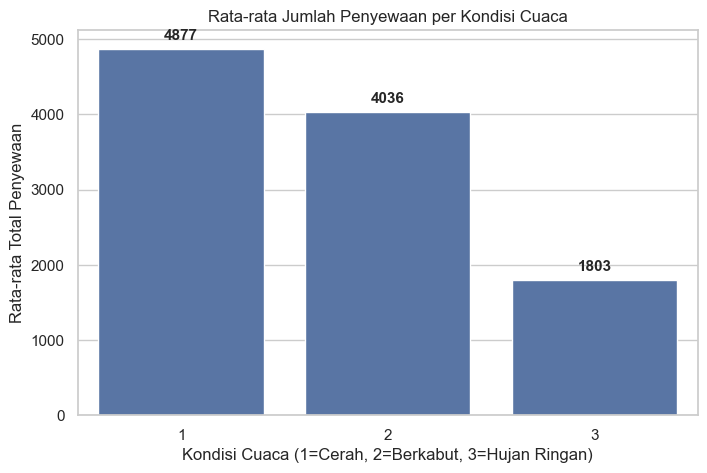

In [17]:
# Group by weathersit
weather_group = day_df.groupby('weathersit')['cnt'].agg(['mean', 'std', 'count']).reset_index()
weather_group.columns = ['weathersit', 'mean_cnt', 'std_cnt', 'count']
display(weather_group)

# Visualisasi
plt.figure(figsize=(8,5))
ax = sns.barplot(data=day_df, x='weathersit', y='cnt', ci=None)
plt.title('Rata-rata Jumlah Penyewaan per Kondisi Cuaca')
plt.xlabel('Kondisi Cuaca (1=Cerah, 2=Berkabut, 3=Hujan Ringan)')
plt.ylabel('Rata-rata Total Penyewaan')

# Menambahkan angka di atas bar
for p in ax.patches:
    ax.annotate(format(p.get_height(), '.0f'),
                (p.get_x() + p.get_width() / 2., p.get_height()),
                ha = 'center', va = 'center',
                xytext = (0, 9),
                textcoords = 'offset points',
                fontsize=11, fontweight='bold')

plt.show()

In [18]:
# Uji ANOVA
from scipy.stats import f_oneway
groups = [day_df[day_df['weathersit']==i]['cnt'] for i in range(1,5) if len(day_df[day_df['weathersit']==i])>0]
f_stat, p_val = f_oneway(*groups)
print(f'ANOVA p-value: {p_val:.5f} (signifikan jika <0.05)')

ANOVA p-value: 0.00000 (signifikan jika <0.05)


**Insight:**
- Kondisi cuaca 1 (cerah) memiliki rata-rata penyewaan tertinggi (4877)
- Cuaca 2 (berkabut/awan) masih cukup tinggi (4036)
- Cuaca 3 (hujan ringan/salju) menurun drastis (1803)
- Distribusi penyewaan pada cuaca 1 dan 2 relatif sama, namun cuaca 3 lebih rendah
- Hasil ANOVA (p-value < 0.05) menegaskan bahwa terdapat perbedaan yang signifikan

Kesimpulan: Cuaca buruk (hujan/salju) mengurangi minat penyewaan sepeda

### Pertanyaan 2: Perbandingan Penyewa Casual vs Registered per Musim dan Tahun

C:\Users\user\AppData\Local\Temp\ipykernel_24644\2619497996.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  season_yr = day_df.groupby(['season', 'yr'])[['casual', 'registered']].mean().reset_index()


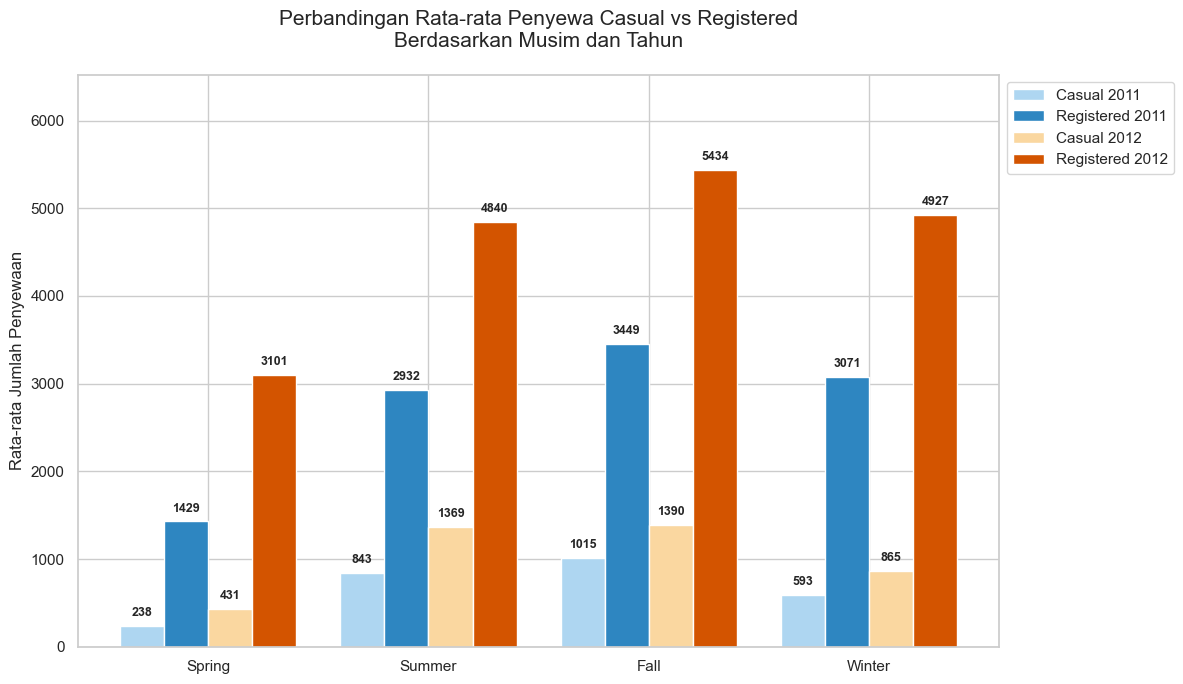

In [19]:
season_yr = day_df.groupby(['season', 'yr'])[['casual', 'registered']].mean().reset_index()

# Mapping season dan year agar lebih deskriptif
season_map = {1:'Spring', 2:'Summer', 3:'Fall', 4:'Winter'}
season_yr['season_name'] = season_yr['season'].map(season_map)
season_yr['yr_label'] = season_yr['yr'].map({0:'2011', 1:'2012'})

# Menyiapkan Plot
fig, ax = plt.subplots(figsize=(12, 7))

# Gunakan bar_width yang lebih kecil (misal: 0.2) agar 4 batang muat dalam 1 kategori
bar_width = 0.2
seasons = season_yr['season_name'].unique()
x = np.arange(len(seasons))

# Membuat Batang untuk masing-masing kategori
# Tahun 2011 (Warna Biru)
subset_2011 = season_yr[season_yr['yr_label'] == '2011']
rects1 = ax.bar(x - 1.5*bar_width, subset_2011['casual'], bar_width, label='Casual 2011', color='#AED6F1')
rects2 = ax.bar(x - 0.5*bar_width, subset_2011['registered'], bar_width, label='Registered 2011', color='#2E86C1')

# Tahun 2012 (Warna Oranye)
subset_2012 = season_yr[season_yr['yr_label'] == '2012']
rects3 = ax.bar(x + 0.5*bar_width, subset_2012['casual'], bar_width, label='Casual 2012', color='#FAD7A0')
rects4 = ax.bar(x + 1.5*bar_width, subset_2012['registered'], bar_width, label='Registered 2012', color='#D35400')

# Fungsi untuk Menambahkan Angka (Data Labels) di atas batang
def autolabel(rects):
    for rect in rects:
        height = rect.get_height()
        ax.annotate(f'{height:.0f}',
                    xy=(rect.get_x() + rect.get_width() / 2, height),
                    xytext=(0, 5),
                    textcoords="offset points",
                    ha='center', va='bottom', fontsize=9, fontweight='bold')

autolabel(rects1)
autolabel(rects2)
autolabel(rects3)
autolabel(rects4)

# Finishing
ax.set_xticks(x)
ax.set_xticklabels(seasons)
ax.set_ylabel('Rata-rata Jumlah Penyewaan', fontsize=12)
ax.set_title('Perbandingan Rata-rata Penyewa Casual vs Registered\nBerdasarkan Musim dan Tahun', fontsize=15, pad=20)
ax.legend(loc='upper left', bbox_to_anchor=(1, 1)) # Meletakkan legenda di luar agar tidak menutupi grafik

# Memberikan ruang tambahan di atas batang agar label angka tidak terpotong
ax.set_ylim(0, season_yr['registered'].max() * 1.2)
plt.tight_layout()
plt.show()

**Insight:**
- Penyewa regitsered selalu lebih tinggi dari casual di semua musim dan di semua tahun
- Tahun 2012 mengalami peningkatan signifikan dibanding 2011, terutama pada musim gugur (Fall)
- Musim semi (Spring) memiliki penyewaan terendah, baik casual maupun registered
- Pertumbuhan bisnis terlihat positif dengan kenaikan rata-rata penyewaan yang hampir dua kali lipat pada tahun 2012 dibanding 2011.

## Analisis Lanjutan (Clustering Manual - Binning)

teknik pengelompokan data dengan membagi rentang nilai ke dalam interval-interval (bin) sehingga terbentuk kelompok-kelompok diskrit yang bisa dianalisis. Dilakukan ini karena pada dataset ini tidak memiliki label alami untuk tingkat permintaan. Lalu binning menciptakan label buatan yang bermakna secara bisnis.

### Membuat Kategori Tingkat Penyewaan (Rental Level)

rental_level
Medium    249
Low       241
High      241
Name: count, dtype: int64


C:\Users\user\AppData\Local\Temp\ipykernel_24644\3207116470.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=day_df, x='rental_level', palette='viridis')


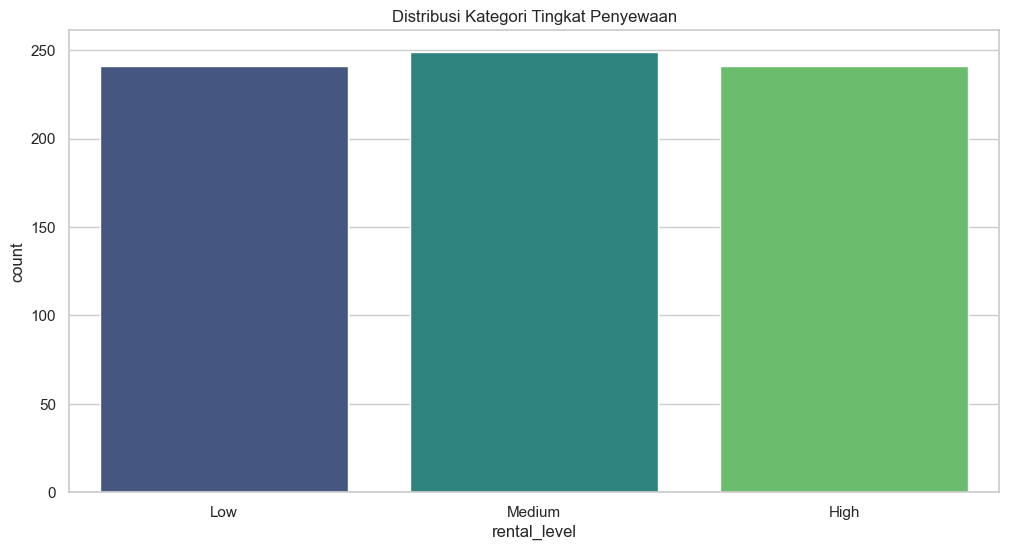

In [20]:
# Definisikan batasan bin berdasarkan persentil
bins = [0, day_df['cnt'].quantile(0.33), day_df['cnt'].quantile(0.67), day_df['cnt'].max()]
labels = ['Low', 'Medium', 'High']
day_df['rental_level'] = pd.cut(day_df['cnt'], bins=bins, labels=labels, include_lowest=True)

# Distribusi
print(day_df['rental_level'].value_counts())
sns.countplot(data=day_df, x='rental_level', palette='viridis')
plt.title('Distribusi Kategori Tingkat Penyewaan')
plt.show()

### Analisis Karakteristik Tiap Kelompok

C:\Users\user\AppData\Local\Temp\ipykernel_24644\1894521382.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  group_stats = day_df.groupby('rental_level')[['temp', 'hum', 'windspeed', 'casual', 'registered']].mean()


,temp,hum,windspeed,casual,registered
rental_level,,,,,
Low,0.333137,0.633098,0.214307,331.871369,1962.568465
Medium,0.554078,0.643230,0.182661,834.124498,3684.915663
High,0.596991,0.606845,0.174749,1379.000000,5320.078838


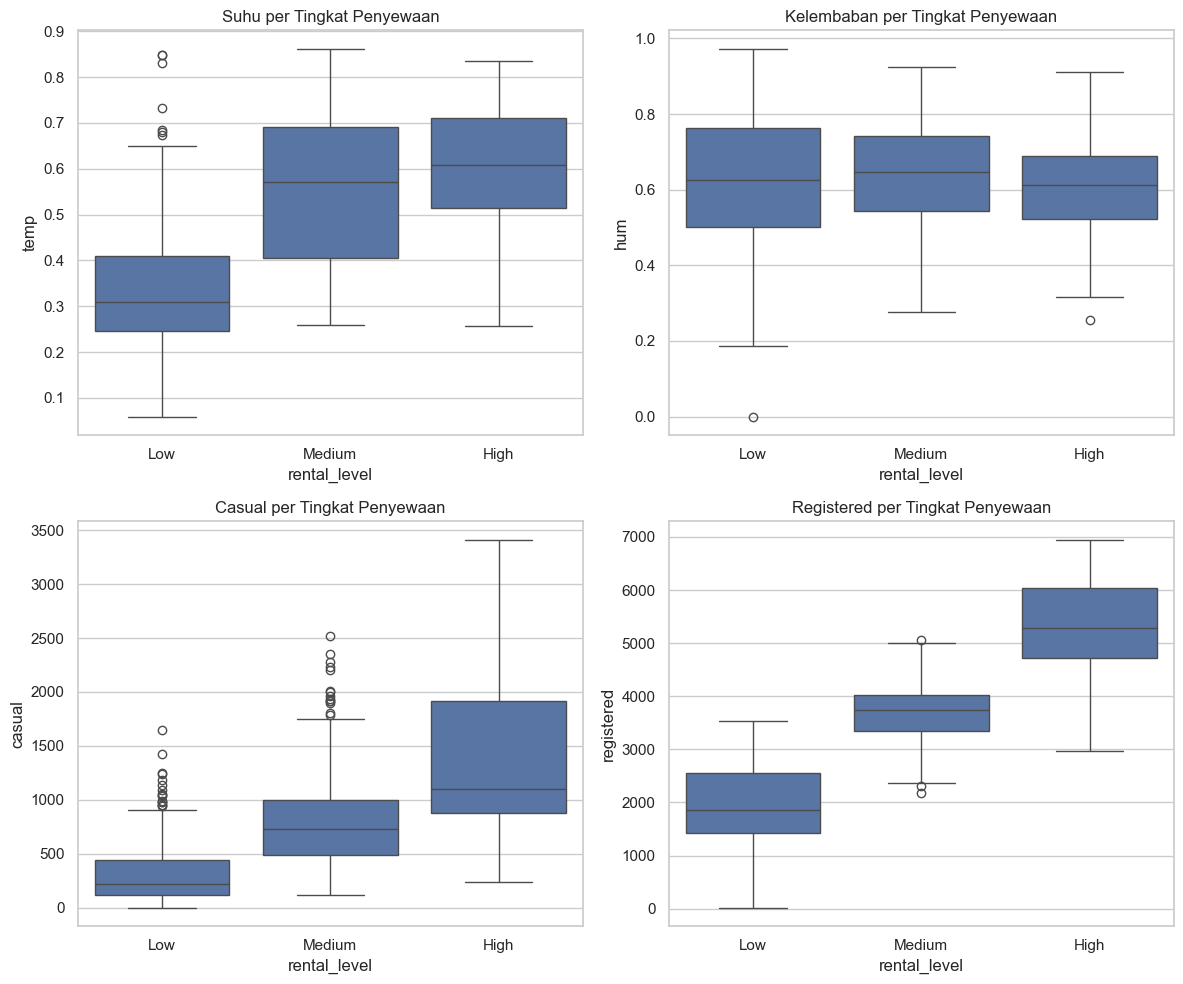

In [21]:
# Rata-rata variabel per kelompok
group_stats = day_df.groupby('rental_level')[['temp', 'hum', 'windspeed', 'casual', 'registered']].mean()
display(group_stats)

# Visualisasi
fig, axes = plt.subplots(2,2, figsize=(12,10))
sns.boxplot(data=day_df, x='rental_level', y='temp', ax=axes[0,0])
axes[0,0].set_title('Suhu per Tingkat Penyewaan')
sns.boxplot(data=day_df, x='rental_level', y='hum', ax=axes[0,1])
axes[0,1].set_title('Kelembaban per Tingkat Penyewaan')
sns.boxplot(data=day_df, x='rental_level', y='casual', ax=axes[1,0])
axes[1,0].set_title('Casual per Tingkat Penyewaan')
sns.boxplot(data=day_df, x='rental_level', y='registered', ax=axes[1,1])
axes[1,1].set_title('Registered per Tingkat Penyewaan')
plt.tight_layout()
plt.show()

Insight:
- Hari dengan tingkat penyewaan Tinggi cenderung memiliki suhu lebih hangat, kelembaban lebih rendah, dan jumlah pengguna registered serta casual jauh lebih tinggi.
- Hari Rendah identik dengan cuaca dingin atau hujan, dan sedikit pengguna.
- Kelompok Medium berada di antara.

### Rekomendasi Bisnis dari Clustering

- High demand days → perlu memastikan ketersediaan sepeda cukup, bisa menerapkan dynamic pricing atau program loyalitas
- Low demand days → dapat diberikan insentif/diskon untuk mendorong penyewaan, terutama bagi pengguna casual
- Medium demand days → potensial untuk kampanye promosi agar naik ke kategori tinggi

## Conclusion

- Conclution pertanyaan 1

Hasil analisis menunjukkan bahwa kondisi cuaca memiliki pengaruh signifikan terhadap jumlah penyewaan sepeda. Pada hari dengan cuaca cerah atau berawan (kategori 1 dan 2), rata-rata penyewaan mencapai sekitar 4.600–4.800 sepeda per hari. Sebaliknya, saat terjadi hujan ringan atau salju (kategori 3), rata-rata penyewaan turun drastis hingga di bawah 2.300 sepeda, atau lebih dari 50%. Uji statistik ANOVA mengonfirmasi bahwa perbedaan antar kelompok cuaca sangat signifikan (p-value < 0,05). Dengan demikian, cuaca buruk menjadi faktor penghambat utama yang perlu diantisipasi, misalnya dengan memberikan insentif atau diskon pada hari-hari hujan untuk tetap menarik minat penyewa.

- Conclution pertanyaan 2

Pengguna terdaftar (registered) mendominasi total penyewaan sepanjang tahun dengan pola yang relatif stabil; puncak tertinggi terjadi pada musim gugur (September–Oktober) dan musim semi (April–Mei). Sementara itu, pengguna casual sangat dipengaruhi oleh musim panas, dengan lonjakan tajam pada bulan Juni hingga Agustus, terutama di bulan Juli. Dari tahun 2011 ke 2012, terjadi peningkatan jumlah penyewaan pada kedua segmen, menandakan pertumbuhan layanan. Strategi pemasaran yang berbeda dapat diterapkan: promosi besar-besaran pada musim panas untuk menarik casual, serta menjaga ketersediaan dan kualitas armada pada musim gugur dan semi untuk mempertahankan loyalitas pengguna registered.

In [22]:
# Simpan main_data.csv untuk dashboard
day_df.to_csv('dashboard/main_data.csv', index=False)
print("main_data.csv saved to dashboard folder.")

main_data.csv saved to dashboard folder.
